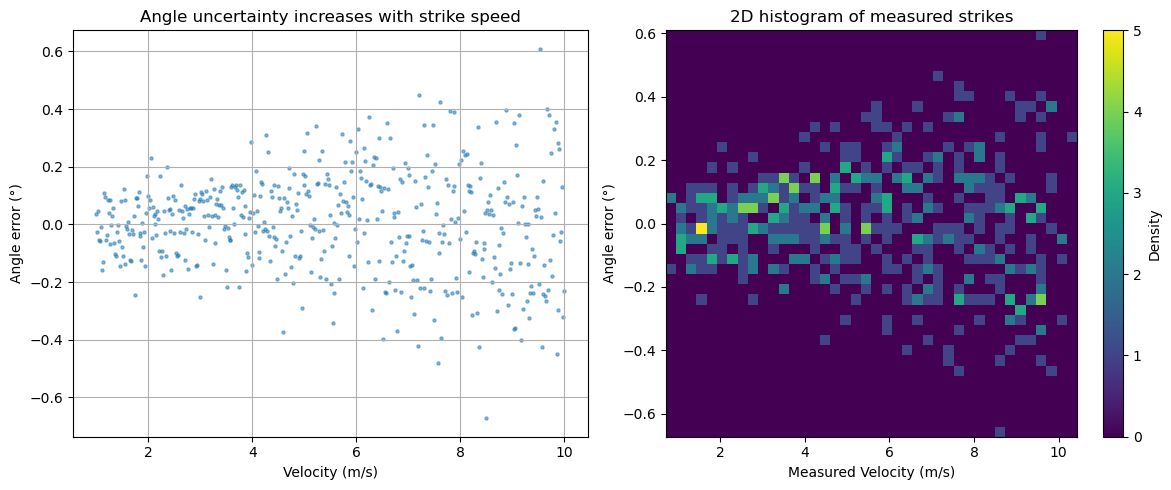

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of samples
N = 500

# Velocity values you attempt (control input)
v_nominal = np.linspace(1, 10, N)  # from soft to powerful strikes

# Define uncertainties:
# Speed uncertainty: constant
sigma_v = 0.2  # m/s

# Angle uncertainty: increases with velocity
def sigma_theta(v):
    return 0.05 + 0.02 * v  # degrees, gets worse with speed

# Generate noisy strikes
v_measured = v_nominal + np.random.normal(0, sigma_v, N)
theta_measured = np.array([
    np.random.normal(0, sigma_theta(v)) for v in v_nominal
])

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(v_nominal, theta_measured, s=5, alpha=0.5)
plt.xlabel("Velocity (m/s)")
plt.ylabel("Angle error (°)")
plt.title("Angle uncertainty increases with strike speed")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist2d(v_measured, theta_measured, bins=40, cmap='viridis')
plt.xlabel("Measured Velocity (m/s)")
plt.ylabel("Angle error (°)")
plt.title("2D histogram of measured strikes")
plt.colorbar(label='Density')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Gear profile and lead error data
# Columns: [Profile Error (µm), Lead Error (µm)]
data = np.array([
    [3.2, 1.1],
    [2.9, 0.9],
    [3.5, 1.4],
    [3.0, 1.0],
    [3.3, 1.2]
])

# Step 1: Compute mean vector
mu = np.mean(data, axis=0)
print(f"Mean vector (µ):\n{mu}\n")

# Step 2: Compute covariance matrix
Sigma = np.cov(data.T, bias=False)  # bias=False ⇒ divide by N-1
print(f"Covariance matrix (Σ):\n{Sigma}\n")

# Step 3: Variance and standard deviation
var_profile = Sigma[0, 0]
var_lead = Sigma[1, 1]
std_profile = np.sqrt(var_profile)
std_lead = np.sqrt(var_lead)

print(f"Variance of profile error: {var_profile:.4f}")
print(f"STD of profile error: {std_profile:.4f}")
print(f"Variance of lead error: {var_lead:.4f}")
print(f"STD of lead error: {std_lead:.4f}\n")

# Step 4: Linear combination: y = x1 + 2 * x2
a = np.array([1, 2])
mu_y = a @ mu
var_y = a @ Sigma @ a
std_y = np.sqrt(var_y)

print(f"Mean of y = x1 + 2*x2: {mu_y:.4f}")
print(f"Variance of y: {var_y:.4f}")
print(f"STD of y: {std_y:.4f}\n")

# Step 5: Chance constraint back-off
alpha = 0.05  # 95% confidence
z = 1.645     # quantile for 95%
backoff = z * std_y
b = 6.0  # tolerance limit

print(f"Back-off term (95%): {backoff:.4f}")
print(f"Required deterministic bound: {b - backoff:.4f}")
print(f"Is the constraint satisfied? {mu_y <= (b - backoff)}")
